Aprendizaje SemiSupervisado

ESTUDIANTE: VALDA PLAZA CAMILA MONSERRAT.
CARRERA: ING. DE SISTEMAS.

SE TRABAJA CON UN DATASET DE CANCIONES REALES DE INFORMACIÓN OBTENIDA DE LA API WEB DE SPOTIFY.

In [75]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Cargar dataset
df = pd.read_csv("C:\monsie\IA\IA CUADERNILLOS\LABORATORIO 7\LAB 7 COMPLETO\Spotify_limpio_sinpopularidad.csv")
df.head()

<>:9: SyntaxWarning: invalid escape sequence '\m'
<>:9: SyntaxWarning: invalid escape sequence '\m'
C:\Users\JESSENIA\AppData\Local\Temp\ipykernel_16616\322124693.py:9: SyntaxWarning: invalid escape sequence '\m'
  df = pd.read_csv("C:\monsie\IA\IA CUADERNILLOS\LABORATORIO 7\LAB 7 COMPLETO\Spotify_limpio_sinpopularidad.csv")


,artist_name,track_id,track_name,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,YG,2RM4jf1Xa9zPgMGRDiht8O,"Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj",0.005820,0.743,238373,0.339,0.000,1,0.0812,-7.678,1,0.4090,203.927,4,0.118
1,YG,1tHDG53xJNGsItRA3vfVgs,BAND DRUM (feat. A$AP Rocky),0.024400,0.846,214800,0.557,0.000,8,0.2860,-7.259,1,0.4570,159.009,4,0.371
2,R3HAB,6Wosx2euFPMT14UXiWudMy,Radio Silence,0.025000,0.603,138913,0.723,0.000,9,0.0824,-5.890,0,0.0454,114.966,4,0.382
3,Chris Cooq,3J2Jpw61sO7l6Hc7qdYV91,Lactose,0.029400,0.800,125381,0.579,0.912,5,0.0994,-12.118,0,0.0701,123.003,4,0.641
4,Chris Cooq,2jbYvQCyPgX3CdmAzeVeuS,Same - Original mix,0.000035,0.783,124016,0.792,0.878,7,0.0332,-10.277,1,0.0661,120.047,4,0.928


In [76]:
df.info()

df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130663 entries, 0 to 130662
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   artist_name       130663 non-null  object 
 1   track_id          130663 non-null  object 
 2   track_name        130662 non-null  object 
 3   acousticness      130663 non-null  float64
 4   danceability      130663 non-null  float64
 5   duration_ms       130663 non-null  int64  
 6   energy            130663 non-null  float64
 7   instrumentalness  130663 non-null  float64
 8   key               130663 non-null  int64  
 9   liveness          130663 non-null  float64
 10  loudness          130663 non-null  float64
 11  mode              130663 non-null  int64  
 12  speechiness       130663 non-null  float64
 13  tempo             130663 non-null  float64
 14  time_signature    130663 non-null  int64  
 15  valence           130663 non-null  float64
dtypes: float64(9), int64

,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
count,130663.000000,130663.000000,1.306630e+05,130663.000000,130663.000000,130663.000000,130663.000000,130663.000000,130663.000000,130663.000000,130663.000000,130663.000000,130663.000000
mean,0.342500,0.581468,2.126331e+05,0.569196,0.224018,5.231894,0.194886,-9.974006,0.607739,0.112015,119.473353,3.878986,0.439630
std,0.345641,0.190077,1.231551e+05,0.260312,0.360328,3.602701,0.167733,6.544379,0.488256,0.124327,30.159636,0.514403,0.259079
min,0.000000,0.000000,3.203000e+03,0.000000,0.000000,0.000000,0.000000,-60.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.031600,0.459000,1.639225e+05,0.396000,0.000000,2.000000,0.097500,-11.898000,0.000000,0.038900,96.014000,4.000000,0.224000
50%,0.203000,0.605000,2.019010e+05,0.603000,0.000149,5.000000,0.124000,-7.979000,1.000000,0.055900,120.027000,4.000000,0.420000
75%,0.636000,0.727000,2.410475e+05,0.775000,0.440000,8.000000,0.236000,-5.684000,1.000000,0.129000,139.642000,4.000000,0.638000
max,0.996000,0.996000,5.610020e+06,1.000000,1.000000,11.000000,0.999000,1.806000,1.000000,0.966000,249.983000,5.000000,1.000000


In [77]:
from sklearn.model_selection import train_test_split

X = df[['danceability','energy','key','loudness','mode','speechiness',
        'acousticness','instrumentalness','liveness','valence','tempo','duration_ms']]


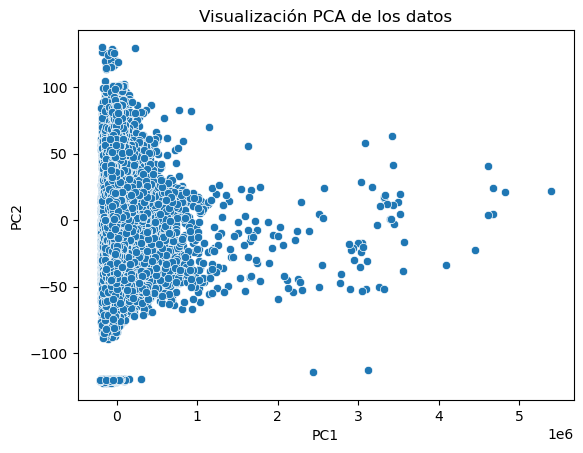

In [78]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
sns.scatterplot(x='PC1', y='PC2', data=df_pca)
plt.title("Visualización PCA de los datos")
plt.show()

El dataset no está etiquetado, es decir, que tenemos solo los dígitos sin la clase (sólo $X$ y no $y$) y tampoco sabemos cuantas clases diferentes tenemos. 

In [79]:
from sklearn.cluster import KMeans

k = 20

kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X)



In [80]:
print(X_digits_dist.shape)
print(X_digits_dist)

(130663, 20)
[[  18312.06648258 3172734.89641847   63463.20127316 ... 4540342.85804066
    54365.09682667  165647.41498123]
 [  41884.8936743  3196307.89526887   39890.16520735 ... 4563915.85736984
    77938.04207892  189220.39669693]
 [ 117771.87606267 3272194.89476991   35996.85375606 ... 4639802.85714609
   153825.03259855  265107.39197235]
 ...
 [ 117493.88153534 3271916.89522123   35718.87104293 ... 4639524.85734699
   153547.03680004  264829.39497174]
 [  76671.87585441 3231094.894796      5103.14750355 ... 4598702.85714822
   112725.0324114   224007.39189764]
 [ 110857.8764217  3265280.89487293   29082.85493264 ... 4632888.85717362
   146911.03289725  258193.39239005]]


In [81]:
import numpy as np

idxs = np.argmin(X_digits_dist, axis=0)
X_representative = X.iloc[idxs]
songs_representative = df.iloc[idxs][["track_name", "artist_name"]]

print("Canciones representativas por cluster:")
print(songs_representative)

Canciones representativas por cluster:
                                               track_name  \
99831                                       Kempe Gowdara   
90134                               Everything That Rises   
54819                                   Why Were You Here   
61003                             Whispering Spiritscapes   
49510                                        O Sacrifício   
730     Das Orgelbüchlein: No. 30, Erstanden ist der h...   
59293                           Worldly Sounds Assortment   
105824  Symphony No. 29 in A Major, K. 201: II. Andant...   
21456                                 I Lost My Innocence   
40548                                                Ever   
45537                               Gorilla (feat. Killa)   
104293  Piano Sonata No. 4 in E-Flat Major, Op. 7: I. ...   
24884                                    A Tale of Rescue   
89697   Le fils des étoiles: Autre musique pour le deu...   
21371                                       Co

In [82]:
print(X_representative.shape)
print(X_representative)

(20, 12)
        danceability   energy  key  loudness  mode  speechiness  acousticness  \
99831          0.759  0.49700    1    -9.829     0       0.0426       0.38900   
90134          0.165  0.19700    7   -18.908     1       0.0480       0.90700   
54819          0.528  0.47700    5   -10.573     1       0.0979       0.29600   
61003          0.259  0.35300    6    -8.522     0       0.0384       0.00735   
49510          0.445  0.71300    9    -8.561     1       0.0597       0.20600   
730            0.163  0.18200    2   -16.411     1       0.0371       0.67100   
59293          0.540  0.18100    9   -41.011     1       0.0579       0.16400   
105824         0.181  0.01860    2   -29.677     1       0.0420       0.98600   
21456          0.725  0.40600    5   -13.118     1       0.0306       0.37800   
40548          0.896  0.36700    1   -10.278     1       0.0825       0.25900   
45537          0.598  0.96200    6    -8.730     0       0.3680       0.24500   
104293         0.33

El siguiente paso consiste en anotar manualmente estas etiquetas.

In [83]:
# DEFINIR GÉNEROS MANUALMENTE
y_representative = [
    'Pop', 'Rock', 'Jazz', 'Hip-Hop', 'Electronic',
    'Reggae', 'Classical', 'Metal', 'Country', 'Funk',
    'Blues', 'Soul', 'R&B', 'Punk', 'Latin',
    'Folk', 'Disco', 'Techno', 'House', 'Alternative'
]

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_representative_encoded = le.fit_transform(y_representative)

print("Géneros asignados:")
for i, (song, artist, genre) in enumerate(zip(songs_representative['track_name'],
                                             songs_representative['artist_name'],
                                             y_representative)):
    print(f"Cluster {i}: {genre} - {song[:30]}... by {artist}")

Géneros asignados:
Cluster 0: Pop - Kempe Gowdara... by Vijay Prakash
Cluster 1: Rock - Everything That Rises... by John Luther Adams
Cluster 2: Jazz - Why Were You Here... by HALP
Cluster 3: Hip-Hop - Whispering Spiritscapes... by Mournful Congregation
Cluster 4: Electronic - O Sacrifício... by Preto no Branco
Cluster 5: Reggae - Das Orgelbüchlein: No. 30, Ers... by Johann Sebastian Bach
Cluster 6: Classical - Worldly Sounds Assortment... by Gentle Whispering
Cluster 7: Metal - Symphony No. 29 in A Major, K.... by Wolfgang Amadeus Mozart
Cluster 8: Country - I Lost My Innocence... by Ezra Furman
Cluster 9: Funk - Ever... by John
Cluster 10: Blues - Gorilla (feat. Killa)... by Hard Head
Cluster 11: Soul - Piano Sonata No. 4 in E-Flat M... by Ludwig van Beethoven
Cluster 12: R&B - A Tale of Rescue... by Davis John Patton
Cluster 13: Punk - Le fils des étoiles: Autre mus... by Erik Satie
Cluster 14: Latin - Communication... by Liquid Mind
Cluster 15: Folk - Depression... by Bangerz
Clust

In [84]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(multi_class="ovr", max_iter=5000, random_state=42)
log_reg.fit(X_representative, y_representative_encoded)

print("Modelo entrenado con", len(X_representative), "muestras representativas")

c:\Users\JESSENIA\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Modelo entrenado con 20 muestras representativas


In [85]:
# PREDECIR EN TODO EL DATASET
predicted_genres_encoded = log_reg.predict(X)
predicted_genres = le.inverse_transform(predicted_genres_encoded)

df['predicted_genre'] = predicted_genres

print("Primeras 10 canciones con géneros predichos:")
print(df[['track_name', 'artist_name', 'predicted_genre']].head(10))

Primeras 10 canciones con géneros predichos:
                                       track_name artist_name predicted_genre
0  Big Bank feat. 2 Chainz, Big Sean, Nicki Minaj          YG      Electronic
1                    BAND DRUM (feat. A$AP Rocky)          YG      Electronic
2                                   Radio Silence       R3HAB           Blues
3                                         Lactose  Chris Cooq           Blues
4                             Same - Original mix  Chris Cooq           Blues
5                       Debauchery - Original mix       Curbo           Blues
6                          Grandma - Original mix  Bingo Play           Blues
7                                     Bon appétit     G Herbo      Electronic
8                            Among - Original mix     34 Feet           Blues
9                           Hazard - Original mix  Chris Cooq           Blues


In [86]:

n_representative = 160 
idxs = np.argsort(X_digits_dist, axis=0)[:n_representative] 
idxs_flat = idxs.flatten() 

X_rep_more = X.iloc[idxs_flat]
y_rep_more = np.repeat(y_representative_encoded, n_representative)

from sklearn.model_selection import train_test_split
X_rep_train, X_rep_test, y_rep_train, y_rep_test = train_test_split(
    X_rep_more, y_rep_more, test_size=0.3, random_state=42, stratify=y_rep_more)

# Entrenar con train
log_reg2 = LogisticRegression(multi_class="ovr", max_iter=5000, random_state=42)
log_reg2.fit(X_rep_train, y_rep_train)

# Evaluar en test
test_score = log_reg2.score(X_rep_test, y_rep_test)
print(f" Precisión en TEST (simulado): {test_score:.2f}")

c:\Users\JESSENIA\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


 Precisión en TEST (simulado): 0.07


In [87]:
train_score = log_reg2.score(X_rep_train, y_rep_train)
print(f"Precisión en entrenamiento: {train_score:.2f}")


Precisión en entrenamiento: 0.08


Distribución de géneros predichos:
predicted_genre
Electronic     35441
Folk           27565
House          18445
Blues          13207
Pop             8726
R&B             7196
Jazz            4558
Reggae          2856
Country         2568
Soul            2135
Hip-Hop         2093
Alternative     1801
Punk            1306
Metal           1268
Latin            944
Rock             516
Disco             13
Funk              10
Techno             8
Classical          7
Name: count, dtype: int64


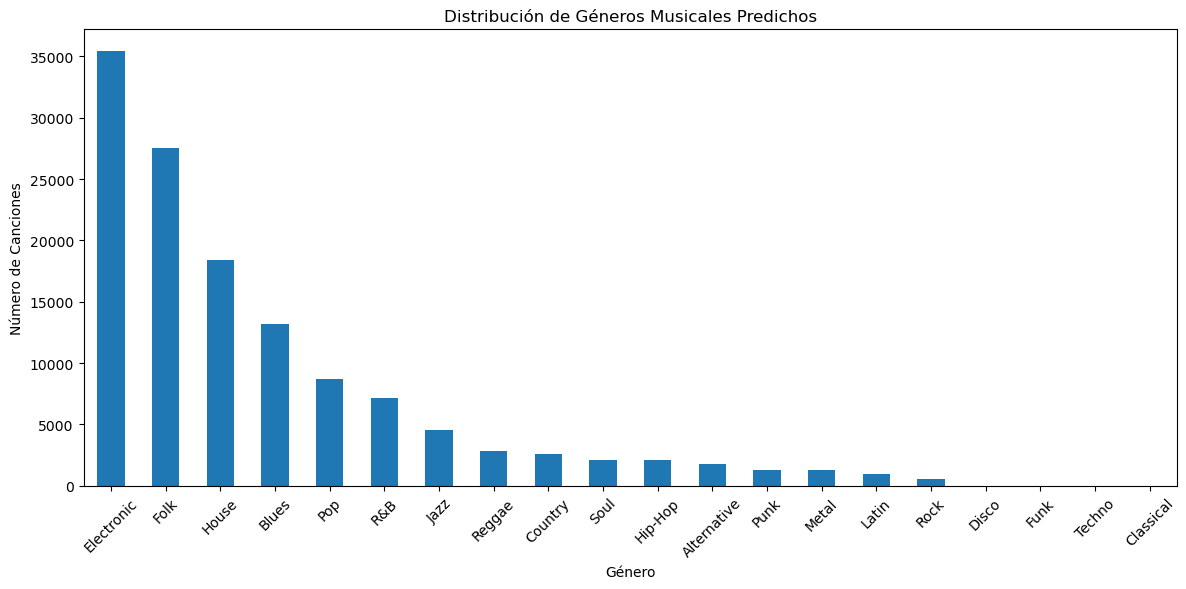

In [88]:
# DISTRIBUCIÓN DE GÉNEROS PREDICHOS
genre_counts = df['predicted_genre'].value_counts()
print("Distribución de géneros predichos:")
print(genre_counts)

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='bar')
plt.title('Distribución de Géneros Musicales Predichos')
plt.xlabel('Género')
plt.ylabel('Número de Canciones')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [89]:
from sklearn.metrics import top_k_accuracy_score
top3 = top_k_accuracy_score(y_rep_test, log_reg2.predict_proba(X_rep_test), k=3)
print(f"Top-3 Accuracy: {top3:.2f}")


Top-3 Accuracy: 0.18


F1-SCORE:

In [90]:
from sklearn.metrics import classification_report
print(classification_report(y_rep_test, log_reg2.predict(X_rep_test)))

              precision    recall  f1-score   support

           0       0.13      0.23      0.16        48
           1       0.07      0.04      0.05        48
           2       0.06      0.06      0.06        48
           3       0.05      0.02      0.03        48
           4       0.04      0.04      0.04        48
           5       0.00      0.00      0.00        48
           6       0.04      0.04      0.04        48
           7       0.12      0.23      0.16        48
           8       0.10      0.02      0.03        48
           9       0.04      0.04      0.04        48
          10       0.00      0.00      0.00        48
          11       0.04      0.08      0.05        48
          12       0.07      0.12      0.09        48
          13       0.04      0.06      0.05        48
          14       0.05      0.02      0.03        48
          15       0.00      0.00      0.00        48
          16       0.09      0.15      0.11        48
          17       0.05    

### Aprendizaje Activo

El aprendizaje activo (o *Active Learning*) consiste en entrenar modelos de ML de manera iterativa, incluyendo en cada iteración nuevas muestras al dataset focalizando en ejemplos en loa que el modelo tenga más problemas.

In [91]:
probas = log_reg2.predict_proba(X_rep_train) 
labels_ixs = np.argmax(probas, axis=1)
labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
sorted_ixs = np.argsort(labels)

uncertain_samples = X_rep_train.iloc[sorted_ixs[:10]]
print(uncertain_samples)



        danceability  energy  key  loudness  mode  speechiness  acousticness  \
33278          0.276   0.864    2    -6.983     1       0.0387       0.00004   
3071           0.294   0.165    2   -12.811     1       0.0453       0.99400   
39167          0.487   0.794    1    -8.432     1       0.0625       0.05790   
50436          0.519   0.388    4   -10.721     1       0.0814       0.58700   
20051          0.579   0.431    8   -10.267     1       0.0293       0.85000   
125590         0.124   0.437    2    -8.210     1       0.0409       0.01280   
43533          0.501   0.625    1    -9.484     1       0.1400       0.06470   
99399          0.510   0.835    3    -4.673     1       0.0447       0.00791   
72349          0.723   0.762    0    -6.262     1       0.1720       0.04090   
103133         0.124   0.182    5   -18.907     1       0.0342       0.48400   

        instrumentalness  liveness  valence    tempo  duration_ms  
33278           0.001360    0.0959    0.488  133.73

In [92]:
k = 10
uncertain_samples = X_rep_train.iloc[sorted_ixs[:k]]
print(uncertain_samples)


        danceability  energy  key  loudness  mode  speechiness  acousticness  \
33278          0.276   0.864    2    -6.983     1       0.0387       0.00004   
3071           0.294   0.165    2   -12.811     1       0.0453       0.99400   
39167          0.487   0.794    1    -8.432     1       0.0625       0.05790   
50436          0.519   0.388    4   -10.721     1       0.0814       0.58700   
20051          0.579   0.431    8   -10.267     1       0.0293       0.85000   
125590         0.124   0.437    2    -8.210     1       0.0409       0.01280   
43533          0.501   0.625    1    -9.484     1       0.1400       0.06470   
99399          0.510   0.835    3    -4.673     1       0.0447       0.00791   
72349          0.723   0.762    0    -6.262     1       0.1720       0.04090   
103133         0.124   0.182    5   -18.907     1       0.0342       0.48400   

        instrumentalness  liveness  valence    tempo  duration_ms  
33278           0.001360    0.0959    0.488  133.73

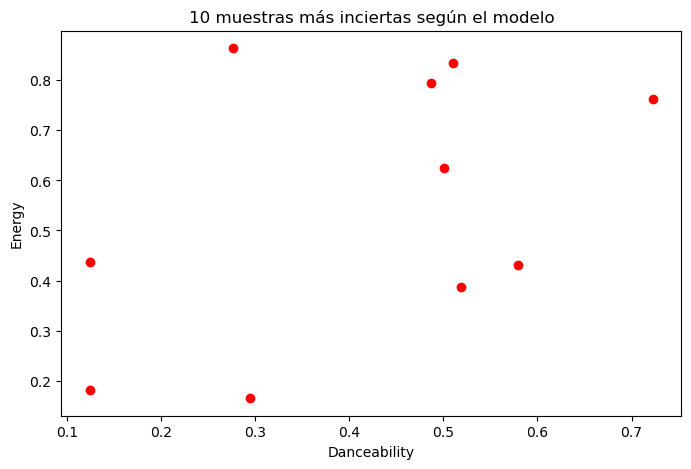

In [93]:
import matplotlib.pyplot as plt

k = 10
uncertain_samples = X_rep_train.iloc[sorted_ixs[:k]]

plt.figure(figsize=(8,5))
plt.scatter(uncertain_samples['danceability'], uncertain_samples['energy'], color='red')
plt.xlabel('Danceability')
plt.ylabel('Energy')
plt.title('10 muestras más inciertas según el modelo')
plt.show()


In [94]:
k = 10
y_lowest = y_rep_train[sorted_ixs[:k]]
y_lowest



array([12, 15, 13, 19, 19, 19, 15, 11, 19, 11])

In [95]:

k = 10
sorted_ixs_subset = sorted_ixs[:k]

y_train2 = y_rep_train.copy() 

y_train2[sorted_ixs_subset] = y_lowest

print(y_train2[sorted_ixs_subset])




[12 15 13 19 19 19 15 11 19 11]


In [96]:
from sklearn.linear_model import LogisticRegression

log_reg5 = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)

# Usar TODO el dataset representativo de entrenamiento
%time log_reg5.fit(X_rep_train, y_train2)

test_score = log_reg5.score(X_rep_test, y_rep_test)
print(f"Precisión en TEST: {test_score:.2f}")



c:\Users\JESSENIA\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


CPU times: total: 438 ms
Wall time: 1.96 s
Precisión en TEST: 0.07


In [97]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

X_data = X_rep_train      # features de entrenamiento
y_data = y_rep_train      # etiquetas de género

X_test_data = X_rep_test
y_test_data = y_rep_test

y_train_active = np.full_like(y_data, -1)   # -1 = desconocida
initial_idx = np.random.choice(len(y_data), 5, replace=False)  
y_train_active[initial_idx] = y_data[initial_idx]

k = 5        # muestras más inciertas por iteración
n_iter = 10  
test_scores = []
uncertain_confidences = []


for i in range(n_iter):
    labeled_mask = y_train_active != -1
    
    model = LogisticRegression(multi_class="ovr", solver="lbfgs", max_iter=5000, random_state=42)
    model.fit(X_data[labeled_mask], y_train_active[labeled_mask])
    
    # Evaluar en test
    score = model.score(X_test_data, y_test_data)
    test_scores.append(score)
    
    unlabeled_mask = y_train_active == -1
    if unlabeled_mask.sum() == 0:
        print("No quedan muestras sin etiquetar. Fin del ciclo.")
        break
    
    probas = model.predict_proba(X_data[unlabeled_mask])
    labels_ixs = np.argmax(probas, axis=1)
    labels = np.array([proba[ix] for proba, ix in zip(probas, labels_ixs)])
    
    sorted_ixs = np.argsort(labels)

    k_actual = min(k, len(sorted_ixs))
    uncertain_ixs = np.arange(len(y_data))[unlabeled_mask][sorted_ixs[:k_actual]]
    
    # Guardar confianzas
    uncertain_confidences.append(labels[sorted_ixs[:k_actual]])
    
    # Propagar etiquetas reales
    y_train_active[uncertain_ixs] = y_data[uncertain_ixs]
    
    print(f"Iteración {i+1}: precisión test={score:.2f}, índices más inciertos={uncertain_ixs}")





Iteración 1: precisión test=0.05, índices más inciertos=[ 521 1459  822 1845 1946]


c:\Users\JESSENIA\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
c:\Users\JESSENIA\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Iteración 2: precisión test=0.06, índices más inciertos=[ 893  493  461 1403 2165]


c:\Users\JESSENIA\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Iteración 3: precisión test=0.06, índices más inciertos=[1951   56 1775 1207 1338]


...

Iteración 8: precisión test=0.06, índices más inciertos=[1136  840  988  776 1930]


c:\Users\JESSENIA\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Iteración 9: precisión test=0.07, índices más inciertos=[2135  979  155 1249 1216]


c:\Users\JESSENIA\anaconda3\envs\mi_entorno\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Iteración 10: precisión test=0.07, índices más inciertos=[ 914  368 1601  428 1487]


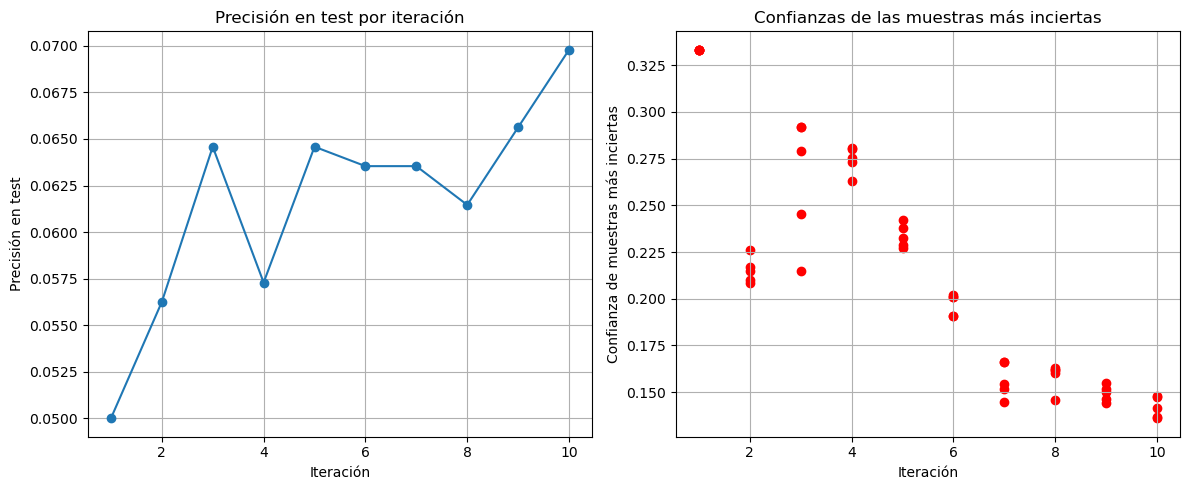

In [98]:
plt.figure(figsize=(12,5))

# Precisión en test
plt.subplot(1,2,1)
plt.plot(range(1, len(test_scores)+1), test_scores, marker='o')
plt.xlabel("Iteración")
plt.ylabel("Precisión en test")
plt.title("Precisión en test por iteración")
plt.grid(True)

# Confianzas de muestras más inciertas
plt.subplot(1,2,2)
for i, conf in enumerate(uncertain_confidences):
    plt.scatter([i+1]*len(conf), conf, color='red')
plt.xlabel("Iteración")
plt.ylabel("Confianza de muestras más inciertas")
plt.title("Confianzas de las muestras más inciertas")
plt.grid(True)

plt.tight_layout()
plt.show()

In [100]:

probs = log_reg.predict_proba(X)

uncertainty = 1 - np.max(probs, axis=1)

k_uncertain = 100
topk_idxs = np.argsort(uncertainty)[-k_uncertain:]
print("Índices más inciertos:", topk_idxs)


Índices más inciertos: [  1817  50436  84508  45238  45259 121545  84194 111131   4452  31160
  17838  37686 116914  14554  21031 120174 122357  59762  47832  34124
 120263 123100  54268  90425  24640  39167 109074  30552  31307 125521
 100889   3071  32299  90807  49971  65444 117297  69454   6705  92821
  28552  57775  29386  67120  29077  57347  36017  81769   9922  42734
  69562  26117   5467  24167  57281  84742  61902  21403 107985 122172
  64817 119951  65295  48342 113252 121446  89945  23479  34966  99040
  43204  33278  35122  89632  99143  65644  48208  10381  10195  18001
  98749  35851  96379  72493  73233  22320  37179  84690  35707  18844
  13373  55286  88022  51651 114791 113023  39096  57153 104629  12321]


In [101]:
# Índices inciertos
topk_idxs = [
1817,50436,84508,45238,45259,121545,84194,111131,4452,31160,
17838,37686,116914,14554,21031,120174,122357,59762,47832,34124,
120263,123100,54268,90425,24640,39167,109074,30552,31307,125521,
100889,3071,32299,90807,49971,65444,117297,69454,6705,92821,
28552,57775,29386,67120,29077,57347,36017,81769,9922,42734,
69562,26117,5467,24167,57281,84742,61902,21403,107985,122172,
64817,119951,65295,48342,113252,121446,89945,23479,34966,99040,
43204,33278,35122,89632,99143,65644,48208,10381,10195,18001,
98749,35851,96379,72493,73233,22320,37179,84690,35707,18844,
13373,55286,88022,51651,114791,113023,39096,57153,104629,12321
]

# Géneros correspondientes
y_new_genres = [
"Electronic","Jazz","Samba","R&B","Country","Hip-Hop","Country","Indie Rock",
"R&B","R&B","Folk","Hip-Hop","Electronic","Folk","Indie Rock","Country",
"Punk","Musical","Post-Punk","Indie Pop",
"Folk","House","Blues","Electronic","Punk","Hip-Hop","Hip-Hop","Funk","R&B","Electronic",
"Country","Jazz","Indie Rock","Electronic","Funk","Blues","R&B","Country","Hip-Hop","Rock",
"Indie Rock","R&B","Pop","Electronic","R&B","Hip-Hop","Rock","Indie Rock","Folk","Jazz",
"Disco","Folk","House","Hip-Hop","Rock","Pop","Electronic","Blues","Country","Indie Rock",
"Rock","Pop Punk","Jazz","Indie Rock","Electronic","Pop","Hip-Hop","Electronic","Folk","Jazz",
"R&B","House","Blues","Hip-Hop","Rock","Funk","Pop","Indie Pop","Jazz","Pop",
"Electronic","Pop","Indie Rock","Folk","Disco","Electronic","Rock","Soul","Disco","Latin"
]


y_new_encoded = le.fit_transform(y_new_genres)

X_new = X.iloc[topk_idxs]

y_new = y_new_encoded


In [102]:

valid_idxs = [idx for idx in topk_idxs if idx in X.index]


y_new_genres_valid = y_new_genres[:len(valid_idxs)]

for idx, genre in zip(valid_idxs, y_new_genres_valid):
    track = X.loc[idx, 'track_name'] if 'track_name' in X.columns else f"Track {idx}"
    artist = X.loc[idx, 'artist_name'] if 'artist_name' in X.columns else f"Artist {idx}"
    print(f"Índice {idx}: {track} - {artist} | Género: {genre}")




Índice 1817: Track 1817 - Artist 1817 | Género: Electronic
Índice 50436: Track 50436 - Artist 50436 | Género: Jazz
Índice 84508: Track 84508 - Artist 84508 | Género: Samba
Índice 45238: Track 45238 - Artist 45238 | Género: R&B
Índice 45259: Track 45259 - Artist 45259 | Género: Country
Índice 121545: Track 121545 - Artist 121545 | Género: Hip-Hop
Índice 84194: Track 84194 - Artist 84194 | Género: Country
Índice 111131: Track 111131 - Artist 111131 | Género: Indie Rock
Índice 4452: Track 4452 - Artist 4452 | Género: R&B
Índice 31160: Track 31160 - Artist 31160 | Género: R&B
Índice 17838: Track 17838 - Artist 17838 | Género: Folk
Índice 37686: Track 37686 - Artist 37686 | Género: Hip-Hop
Índice 116914: Track 116914 - Artist 116914 | Género: Electronic
Índice 14554: Track 14554 - Artist 14554 | Género: Folk
Índice 21031: Track 21031 - Artist 21031 | Género: Indie Rock
Índice 120174: Track 120174 - Artist 120174 | Género: Country
Índice 122357: Track 122357 - Artist 122357 | Género: Punk
Ín